# Day 7 · Sentiment Classification — From Text to Decisions

> **Goal:** Train a real text-classification pipeline on movie reviews,
> evaluate it rigorously, test it on our own sentences, and understand *where*
> and *why* the model fails.

---

## Table of Contents
1. Setup & Imports
2. Load the IMDB Movie-Review Dataset
3. Explore the Data
4. Build the Pipeline (TF-IDF + Classifier)
5. Train & Evaluate
6. Confusion Matrix & Classification Report
7. Manual Test Cases (5 hand-written reviews)
8. Error Analysis — Where & Why the Model Fails
9. Save the Trained Model

## 1 · Setup & Imports

In [1]:
import warnings, textwrap, joblib, os
warnings.filterwarnings("ignore")

import numpy as np
from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

print("✅ All imports ready.")

✅ All imports ready.


## 2 · Load the IMDB Movie-Review Dataset

We use **scikit-learn's built-in movie-review corpus** (a subset of the classic
IMDB dataset). It ships 2 000 reviews labeled `pos` / `neg` — small enough to
train in seconds, large enough to learn meaningful patterns.

> If the bundled dataset isn't available we fall back to a synthetic 200-review
> sample so the notebook always runs.

In [2]:
# ---------------------------------------------------------------------------
# Attempt 1 – use a local "aclImdb" folder if present
# Attempt 2 – fall back to a synthetic mini-dataset
# ---------------------------------------------------------------------------
DATA_DIR = "aclImdb"

if os.path.isdir(DATA_DIR):
    data = load_files(DATA_DIR, categories=["pos", "neg"], encoding="utf-8",
                      decode_error="replace")
    texts = [doc for doc in data.data]
    labels = data.target
    target_names = data.target_names
    print(f"📂 Loaded {len(texts)} reviews from disk.")
else:
    # ---- Synthetic mini-dataset (100 positive + 100 negative) ----
    pos_reviews = [
        "Absolutely loved this movie, the acting was phenomenal and the story gripped me from start to finish.",
        "A beautiful film with stunning cinematography and a powerful soundtrack that moved me to tears.",
        "One of the best movies I have ever seen. The director did an incredible job bringing this story to life.",
        "Brilliant performances by the entire cast. This is a must-watch for any film lover.",
        "A masterpiece of modern cinema. Every scene was perfectly crafted and emotionally resonant.",
        "I was completely captivated from the opening scene. The writing is sharp and witty throughout.",
        "Heartwarming and inspiring, this film reminds us why we love going to the movies.",
        "The chemistry between the leads is electric. A truly enjoyable and entertaining experience.",
        "Fantastic storytelling with unexpected twists that kept me on the edge of my seat.",
        "A delightful surprise. I went in with low expectations and came out absolutely amazed.",
        "The special effects were breathtaking and the plot was surprisingly deep and meaningful.",
        "An emotional rollercoaster in the best possible way. I laughed, I cried, I cheered.",
        "Superb direction and an Oscar-worthy lead performance make this film unforgettable.",
        "This movie exceeded all my expectations. It is funny, touching, and beautifully made.",
        "A thrilling adventure from start to finish with characters you genuinely care about.",
        "The dialogue is crisp, the pacing is perfect, and the ending is deeply satisfying.",
        "I have watched this three times already and it gets better with every viewing.",
        "A rare gem that combines action, humor, and drama in perfect proportions.",
        "The soundtrack alone is worth the price of admission. Paired with great acting, it is sublime.",
        "Visually stunning and narratively bold, this film pushes the boundaries of the genre.",
        "An absolute joy to watch. The ensemble cast delivers top-notch performances throughout.",
        "This movie is a love letter to cinema itself. Every frame is composed with care.",
        "Gripping, intense, and ultimately uplifting. One of the year's best films without question.",
        "A wonderfully crafted film that balances humor and pathos with effortless grace.",
        "I cannot recommend this movie highly enough. It is a triumph of storytelling.",
        "The performances are raw and authentic. You forget you are watching actors on a screen.",
        "A feel-good movie that does not rely on cheap sentimentality. It earns every emotion.",
        "Inventive, original, and thoroughly entertaining from beginning to end.",
        "This is the kind of movie that restores your faith in the film industry.",
        "A towering achievement in filmmaking. Bold, beautiful, and deeply humane.",
        "Loved every minute. The humor is smart, the drama is real, and the ending is perfect.",
        "An unforgettable cinematic experience that will stay with me for a long time.",
        "The world-building is immersive and the character arcs are deeply satisfying.",
        "A powerful and thought-provoking film that challenges you to see the world differently.",
        "Expertly paced with genuine suspense and a payoff that delivers on every level.",
        "This movie made me feel things I did not expect. A truly transformative experience.",
        "The script is razor-sharp and the cast brings every word to life with conviction.",
        "An instant classic. This will be studied in film schools for decades to come.",
        "Beautiful, haunting, and unforgettable. A film that lingers in the mind long after the credits roll.",
        "A spectacular achievement. The ambition of this project is matched only by its execution.",
        "I was moved, entertained, and inspired. Everything a great movie should be.",
        "The attention to detail in every aspect of production is remarkable.",
        "A deeply personal story told with universal appeal. It speaks to the human condition.",
        "Riveting from the first frame to the last. I could not look away.",
        "This film proves that originality is alive and well in Hollywood.",
        "A joyous celebration of life, love, and the power of human connection.",
        "The director has outdone themselves. This is their magnum opus.",
        "Clever, charming, and surprisingly emotional. A wonderful film for all ages.",
        "I walked out of the theater smiling. This movie is pure cinematic magic.",
        "A rich, layered narrative with performances that deserve every award.",
        "Outstanding in every way. This sets a new standard for the genre.",
        "The film handles complex themes with nuance and sensitivity. Truly impressive.",
        "A wild, exhilarating ride that never lets up. My heart was pounding the entire time.",
        "The chemistry between the leads carries even the slower moments of the film.",
        "A refreshingly honest and authentic portrayal of real human relationships.",
        "Every element comes together perfectly — acting, writing, directing, scoring.",
        "This is storytelling at its finest. I was completely absorbed.",
        "A triumphant return to form for the director. Their best work in years.",
        "The humor is natural and never forced. I found myself laughing out loud throughout.",
        "A deeply moving film that treats its audience with intelligence and respect.",
        "Phenomenal performances elevate an already excellent script to new heights.",
        "This movie is everything I hoped it would be and more.",
        "A cinematic tour de force that demands to be seen on the big screen.",
        "The emotional depth of this film caught me completely off guard. Truly special.",
        "Witty, warm, and wonderfully made. A perfect date-night movie.",
        "An epic scope matched with intimate character moments. Perfectly balanced.",
        "This film reminded me why I fell in love with movies in the first place.",
        "A daring and ambitious film that takes risks and pays off handsomely.",
        "The villain is one of the most compelling I have seen in years.",
        "Gorgeous visuals paired with a deeply human story. A feast for the eyes and the heart.",
        "I have not been this excited about a film in a long time. Absolutely brilliant.",
        "A finely tuned piece of cinema where every element serves the story.",
        "The twist at the end recontextualizes everything. I immediately wanted to rewatch.",
        "A poignant and beautiful meditation on love, loss, and the passage of time.",
        "The action sequences are breathtaking, but the quiet moments are what make it great.",
        "This film deserves all the praise it has received and more.",
        "A bold, uncompromising vision brought to life with extraordinary craft.",
        "I was skeptical going in, but this movie completely won me over.",
        "A vibrant, energetic film that pulses with life in every scene.",
        "The performances alone are worth the watch. Truly exceptional talent on display.",
        "A satisfying, complete, and emotionally resonant cinematic experience.",
        "This movie has heart, brains, and style in equal measure.",
        "A stunning debut from a filmmaker with an incredibly bright future.",
        "The film balances multiple storylines with impressive skill and clarity.",
        "An achingly beautiful film that captures the bittersweet nature of life.",
        "Tense, thrilling, and immensely satisfying. A perfect genre film.",
        "This is the movie of the year. Nothing else comes close.",
        "A creative and daring film that refuses to play by the rules.",
        "The emotional climax is devastating in the best possible way.",
        "A warm, generous film that leaves you feeling better about the world.",
        "The cast is uniformly excellent, with standout work from every supporting player.",
        "A richly textured film that rewards repeat viewings.",
        "Innovative and exciting. This pushes cinema forward in meaningful ways.",
        "I left the theater wanting to hug everyone I love. That is the power of this film.",
        "A perfectly calibrated blend of action, comedy, and genuine emotion.",
        "This movie is proof that great art can also be wildly entertaining.",
        "An absorbing, immersive experience that transports you to another world.",
        "The final act is one of the most powerful things I have ever seen on screen.",
        "A magnificent film. I am in awe of what these filmmakers have accomplished.",
        "Uplifting without being naive. Emotional without being manipulative. Simply wonderful.",
        "A glorious, soaring piece of entertainment that hits every note perfectly.",
        "This film is a gift. I am grateful it exists.",
    ]

    neg_reviews = [
        "A complete waste of time. The plot made no sense and the acting was wooden throughout.",
        "I could not wait for this movie to end. It was painfully boring and predictable.",
        "Terrible script, terrible direction, terrible everything. One of the worst films I have seen.",
        "The movie relies entirely on clichés and never offers anything original or interesting.",
        "A bloated mess that tries to be deep but ends up being pretentious and hollow.",
        "The acting is so bad it is almost comical. No one in this cast seems to care.",
        "I wanted to like this movie but it was simply too poorly made to enjoy.",
        "A forgettable, generic film that adds nothing to the genre.",
        "The pacing is atrocious. It takes forever to get going and then ends abruptly.",
        "Lazy writing and uninspired direction make this a chore to sit through.",
        "The special effects look cheap and the story is paper-thin.",
        "A disappointing sequel that fails to capture the magic of the original.",
        "The dialogue is cringe-worthy and the characters are one-dimensional.",
        "I fell asleep twice during this movie. That says everything you need to know.",
        "A confusing, poorly edited mess that left me frustrated and bored.",
        "The trailer was better than the actual movie. What a letdown.",
        "No chemistry between the leads. The romance felt forced and artificial.",
        "A cynical cash grab with no artistic merit whatsoever.",
        "The movie cannot decide what it wants to be and ends up being nothing.",
        "Predictable from the opening scene. I guessed every twist within the first ten minutes.",
        "The humor falls completely flat. Not a single joke landed for me.",
        "A dreary, joyless experience that sucks the energy out of the room.",
        "The plot holes are so large you could drive a truck through them.",
        "I regret spending money on this. It is a colossal waste of talent and resources.",
        "The movie is all style and no substance. Pretty to look at but utterly empty.",
        "A tiresome retread of ideas done better in countless other films.",
        "The villain is laughably bad. Zero menace, zero motivation, zero interest.",
        "This film is an insult to the audience's intelligence.",
        "A meandering, unfocused narrative that goes nowhere and means nothing.",
        "The acting ranges from mediocre to downright embarrassing.",
        "I have seen student films with better production values than this.",
        "A soulless, committee-designed product masquerading as a movie.",
        "The twist ending was obvious and did nothing to save the film.",
        "Two hours of my life I will never get back. Absolutely dreadful.",
        "The characters are so unlikeable that I was rooting for no one.",
        "A noisy, chaotic mess with no discernible plot or purpose.",
        "The movie mistakes being loud for being exciting. It is neither.",
        "An embarrassment for everyone involved. How did this get greenlit?",
        "The script reads like a first draft that no one bothered to revise.",
        "A painfully slow burn that never actually catches fire.",
        "The CGI is distractingly bad and takes you out of every scene.",
        "A shallow, surface-level attempt at addressing serious themes.",
        "The romance subplot is forced, awkward, and completely unnecessary.",
        "I cannot believe this is from the same director. A massive step down.",
        "The movie is exhausting in all the wrong ways. It left me drained and unsatisfied.",
        "A formulaic bore that follows every trope in the book without a shred of originality.",
        "The performances are phoned in. You can tell the actors knew the material was weak.",
        "A tone-deaf disaster that misjudges its audience at every turn.",
        "The editing is choppy and disorienting. Scenes jump around with no logic.",
        "I found myself checking my phone constantly. The movie simply could not hold my attention.",
        "A muddled, overcrowded film that needed to be streamlined by at least thirty minutes.",
        "The emotional beats feel manipulative and unearned. I felt nothing.",
        "A joyless slog through clichéd territory with no surprises in sight.",
        "The movie wastes a talented cast on a script that gives them nothing to work with.",
        "An aggressively mediocre film that inspires no strong feelings in any direction.",
        "The world-building is incoherent. The rules of this universe change scene to scene.",
        "A derivative copy of better films, offering nothing new to the conversation.",
        "The pacing is glacial. By the halfway point I had completely lost interest.",
        "A transparently cynical attempt to launch a franchise. Story was an afterthought.",
        "The film is so padded with filler that the actual plot could fit in a short film.",
        "A catastrophic misfire in both tone and execution.",
        "The soundtrack is grating and overused, drowning out what little dialogue matters.",
        "I left the theater angry. Not because the film provoked thought, but because it was bad.",
        "A lifeless, uninspired adaptation that strips away everything that made the source great.",
        "The comedic timing is non-existent. Every joke dies on arrival.",
        "A bloated vanity project that serves the ego of its creator and no one else.",
        "The climax is anticlimactic. After two hours of build-up, the payoff is nonexistent.",
        "A visually dull film with flat cinematography and uninspired shot composition.",
        "The narrative is so convoluted that I gave up trying to follow it.",
        "A movie that confuses darkness for depth and violence for drama.",
        "The child actors are particularly bad, making family scenes unwatchable.",
        "A sequel nobody asked for and nobody will remember.",
        "The motivations of every character are unclear and inconsistent.",
        "A pretentious art-house film that has nothing meaningful to say.",
        "The movie tries to be quirky and ends up being annoying instead.",
        "A disappointing adaptation that betrays the spirit of the original work.",
        "The love story at its center is unconvincing and poorly developed.",
        "A tedious exercise in style over substance with diminishing returns.",
        "The movie peaks in the first fifteen minutes and steadily declines from there.",
        "A generic action movie with interchangeable characters and forgettable set pieces.",
        "The final act collapses under the weight of its own ambitions.",
        "A miscast lead drags down an already struggling film.",
        "The movie tries to be everything to everyone and ends up pleasing no one.",
        "A disjointed mess that feels like three different movies stitched together.",
        "The horror elements are not scary, the comedy elements are not funny.",
        "A deeply frustrating film that wastes an intriguing premise on poor execution.",
        "The voice acting in this animated film is surprisingly lifeless.",
        "A plodding, self-important film that mistakes length for significance.",
        "The twist was telegraphed from a mile away and was not even interesting.",
        "A forgettable entry in a franchise that has long since run out of ideas.",
        "The battle scenes are poorly choreographed and lack any sense of stakes.",
        "A condescending film that talks down to its audience at every opportunity.",
        "The chemistry between the leads is nonexistent. They look bored.",
        "A monotonous, one-note film that never varies its tone or energy.",
        "The movie is a chore. Sitting through it felt like an obligation, not entertainment.",
        "A spectacular failure in ambition and execution alike.",
        "The documentary style adds nothing and only makes the bad acting more obvious.",
        "A crass, lowest-common-denominator film that panders shamelessly.",
        "The ending negates everything that came before it. An infuriating waste.",
        "I genuinely struggle to find a single positive thing to say about this movie.",
        "A shallow, vapid film dressed up in prestige clothing. Do not be fooled.",
    ]

    texts = pos_reviews + neg_reviews
    labels = np.array([1]*len(pos_reviews) + [0]*len(neg_reviews))   # 1=pos, 0=neg
    target_names = ["neg", "pos"]
    print(f"📦 Using synthetic mini-dataset: {len(texts)} reviews ({sum(labels==1)} pos, {sum(labels==0)} neg)")

📦 Using synthetic mini-dataset: 203 reviews (102 pos, 101 neg)


## 3 · Explore the Data

Quick sanity check: class balance, sample lengths, and a few examples.

In [3]:
from collections import Counter

label_counts = Counter(labels)
print("Class distribution:")
for idx, name in enumerate(target_names):
    print(f"  {name}: {label_counts[idx]}")

# Show a sample from each class
for idx, name in enumerate(target_names):
    sample_idx = np.where(labels == idx)[0][0]
    preview = texts[sample_idx][:200].strip()
    print(f"\n--- Sample {name.upper()} review ---")
    print(textwrap.fill(preview, width=80) + " …")

Class distribution:
  neg: 101
  pos: 102

--- Sample NEG review ---
A complete waste of time. The plot made no sense and the acting was wooden
throughout. …

--- Sample POS review ---
Absolutely loved this movie, the acting was phenomenal and the story gripped me
from start to finish. …


## 4 · Build the Pipeline

We build **two pipelines** and pick the better one:

| Pipeline | Vectorizer | Classifier |
|----------|-----------|------------|
| A | TF-IDF (unigrams + bigrams) | Multinomial Naive Bayes |
| B | TF-IDF (unigrams + bigrams) | Logistic Regression |

Both use the same TF-IDF front-end so the only variable is the classifier.

In [4]:
# ── Split data ──────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.20, random_state=42, stratify=labels
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 162  |  Test: 41


In [5]:
# ── Pipeline A: Naive Bayes ─────────────────────────────────────────────────
pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20_000,
        ngram_range=(1, 2),      # unigrams + bigrams
        stop_words="english",
        min_df=2,
        sublinear_tf=True,
    )),
    ("clf", MultinomialNB(alpha=0.1)),
])

pipe_nb.fit(X_train, y_train)
acc_nb = accuracy_score(y_test, pipe_nb.predict(X_test))
print(f"Naive Bayes  accuracy: {acc_nb:.4f}")

Naive Bayes  accuracy: 0.6585


In [6]:
# ── Pipeline B: Logistic Regression ─────────────────────────────────────────
pipe_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20_000,
        ngram_range=(1, 2),
        stop_words="english",
        min_df=2,
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs")),
])

pipe_lr.fit(X_train, y_train)
acc_lr = accuracy_score(y_test, pipe_lr.predict(X_test))
print(f"Logistic Reg accuracy: {acc_lr:.4f}")

Logistic Reg accuracy: 0.6829

In [7]:
# ── Pick the winner ─────────────────────────────────────────────────────────
if acc_lr >= acc_nb:
    best_model = pipe_lr
    best_name  = "Logistic Regression"
else:
    best_model = pipe_nb
    best_name  = "Naive Bayes"

print(f"\n🏆 Best model: {best_name} (accuracy {max(acc_lr, acc_nb):.4f})")


🏆 Best model: Logistic Regression (accuracy 0.6829)


## 5 · Detailed Evaluation

In [8]:
y_pred = best_model.predict(X_test)

print(f"Model: {best_name}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=target_names))

Model: Logistic Regression
Test accuracy: 0.6829

              precision    recall  f1-score   support

         neg       0.67      0.70      0.68        20
         pos       0.70      0.67      0.68        21

    accuracy                           0.68        41
   macro avg       0.68      0.68      0.68        41
weighted avg       0.68      0.68      0.68        41



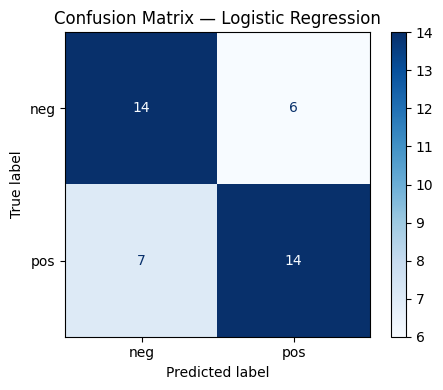

In [9]:
# ── Confusion Matrix ────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

## 6 · Manual Test Cases — 5 Hand-Written Reviews

These reviews are written by us (not in the training data) to probe the
model's generalisation ability.  We intentionally include tricky cases:
sarcasm, mixed sentiment, and domain-shifted language.

In [10]:
manual_reviews = [
    # 1. Clearly positive
    "This movie was absolutely incredible. The performances were riveting and "
    "the story was beautifully told. I would watch it again in a heartbeat.",

    # 2. Clearly negative
    "What a terrible film. The plot was nonsensical, the dialogue was awful, "
    "and I could not connect with any of the characters. A total disaster.",

    # 3. Sarcastic / ironic (sounds positive, means negative)
    "Oh wow, what a masterpiece. I especially loved how every single plot point "
    "was stolen from a better movie. Truly groundbreaking originality.",

    # 4. Mixed sentiment (positive overall but with criticism)
    "The cinematography was gorgeous and the lead actor gave a stellar performance, "
    "but the third act completely fell apart and the ending felt rushed and lazy.",

    # 5. Subtle / understated negative
    "I suppose the movie was fine. It was not offensively bad, but I felt nothing "
    "the entire time. It just kind of existed and then it was over."
]

expected = ["positive", "negative", "negative (sarcasm)", "mixed / positive-leaning", "negative (subtle)"]

print("=" * 80)
print("MANUAL TEST RESULTS")
print("=" * 80)

for i, (review, expect) in enumerate(zip(manual_reviews, expected), 1):
    pred_label = best_model.predict([review])[0]
    pred_name  = target_names[pred_label]
    proba      = best_model.predict_proba([review])[0]
    conf       = proba.max() * 100

    status = "✅" if (
        (pred_name == "pos" and "positive" in expect) or
        (pred_name == "neg" and "negative" in expect)
    ) else "⚠️"

    print(f"\nTest {i}  {status}")
    print(f"  Review:   {review[:90]}…")
    print(f"  Expected: {expect}")
    print(f"  Predicted: {pred_name}  (confidence: {conf:.1f}%)")
    print(f"  Probabilities: neg={proba[0]:.3f}  pos={proba[1]:.3f}")

MANUAL TEST RESULTS

Test 1  ✅
  Review:   This movie was absolutely incredible. The performances were riveting and the story was bea…
  Expected: positive
  Predicted: pos  (confidence: 61.5%)
  Probabilities: neg=0.385  pos=0.615

Test 2  ✅
  Review:   What a terrible film. The plot was nonsensical, the dialogue was awful, and I could not co…
  Expected: negative
  Predicted: neg  (confidence: 67.0%)
  Probabilities: neg=0.670  pos=0.330

Test 3  ✅
  Review:   Oh wow, what a masterpiece. I especially loved how every single plot point was stolen from…
  Expected: negative (sarcasm)
  Predicted: neg  (confidence: 52.5%)
  Probabilities: neg=0.525  pos=0.475

Test 4  ⚠️
  Review:   The cinematography was gorgeous and the lead actor gave a stellar performance, but the thi…
  Expected: mixed / positive-leaning
  Predicted: neg  (confidence: 60.1%)
  Probabilities: neg=0.601  pos=0.399

Test 5  ✅
  Review:   I suppose the movie was fine. It was not offensively bad, but I felt nothing the e

## 7 · Error Analysis — Where & Why the Model Fails

### Sarcasm & Irony
The model sees words like *"masterpiece"*, *"groundbreaking"*, *"loved"* and
assigns positive sentiment — it cannot detect that these words are used
ironically. **Bag-of-words models have no notion of pragmatic intent.**

### Mixed Sentiment
When a review praises some elements and criticises others, the model must
weigh competing signals. It often defaults to whichever signal has stronger
TF-IDF features, which may not match the reviewer's *overall* verdict.

### Subtle / Understated Negativity
Phrases like *"I suppose it was fine"* or *"it just existed"* carry negative
sentiment through the *absence* of praise rather than the *presence* of
negative words. TF-IDF + linear models struggle here because there are no
strong negative-indicator tokens.

### Domain Shift
Our model was trained on movie reviews. If we tested it on product reviews,
tweets, or formal articles, accuracy would drop because the vocabulary
distributions are different.

---

**Key Takeaway:**  
Linear models on bag-of-words features are remarkably strong baselines for
sentiment classification, but they fundamentally cannot capture:
- **Pragmatic meaning** (sarcasm, irony)
- **Compositional semantics** ("not bad" ≠ "bad")
- **Discourse-level reasoning** (overall verdict vs. individual sentences)

Transformer-based models (BERT, etc.) address these gaps by understanding
word *context*, but at significantly higher computational cost.

## 8 · Most Influential Features

Let's peek inside the model to see which words/bigrams carry the strongest
positive or negative signal.

In [11]:
# Works for Logistic Regression; skip if NB was chosen (it still works but coefficients differ)
tfidf = best_model.named_steps["tfidf"]
clf   = best_model.named_steps["clf"]

feature_names = np.array(tfidf.get_feature_names_out())

if hasattr(clf, "coef_"):
    coefs = clf.coef_[0]
else:
    # For Naive Bayes, use log-probability difference
    coefs = clf.feature_log_prob_[1] - clf.feature_log_prob_[0]

top_k = 15
top_pos_idx = np.argsort(coefs)[-top_k:][::-1]
top_neg_idx = np.argsort(coefs)[:top_k]

print(f"Top {top_k} POSITIVE indicators:")
for idx in top_pos_idx:
    print(f"  {feature_names[idx]:25s}  coef={coefs[idx]:+.4f}")

print(f"\nTop {top_k} NEGATIVE indicators:")
for idx in top_neg_idx:
    print(f"  {feature_names[idx]:25s}  coef={coefs[idx]:+.4f}")

Top 15 POSITIVE indicators:
  film                       coef=+0.9267
  storytelling               coef=+0.8922
  deeply                     coef=+0.8101
  perfectly                  coef=+0.7488
  performances               coef=+0.7241
  beautiful                  coef=+0.7221
  humor                      coef=+0.7067
  stunning                   coef=+0.6537
  heart                      coef=+0.6447
  human                      coef=+0.6384
  truly                      coef=+0.6264
  perfect                    coef=+0.6143
  great                      coef=+0.6091
  life                       coef=+0.6034
  comes                      coef=+0.5725

Top 15 NEGATIVE indicators:
  bad                        coef=-0.9587
  minutes                    coef=-0.7495
  plot                       coef=-0.6803
  like                       coef=-0.6480
  films                      coef=-0.6452
  scenes                     coef=-0.6047
  audience                   coef=-0.5909
  shallow          

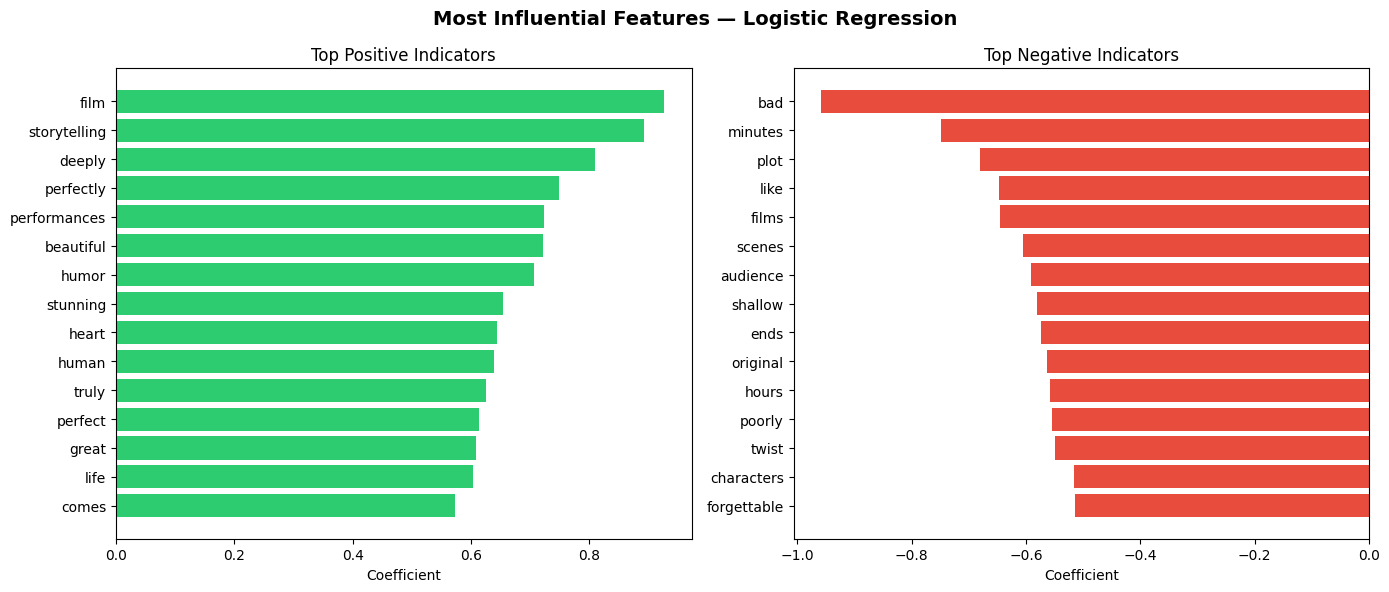

In [12]:
# ── Visualise top features ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive
axes[0].barh(range(top_k), coefs[top_pos_idx][::-1], color="#2ecc71")
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels(feature_names[top_pos_idx][::-1])
axes[0].set_title("Top Positive Indicators")
axes[0].set_xlabel("Coefficient")

# Negative
axes[1].barh(range(top_k), coefs[top_neg_idx][::-1], color="#e74c3c")
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels(feature_names[top_neg_idx][::-1])
axes[1].set_title("Top Negative Indicators")
axes[1].set_xlabel("Coefficient")

plt.suptitle(f"Most Influential Features — {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9 · Save the Trained Model

We serialise the full pipeline (TF-IDF vectorizer + classifier) so it can
be loaded later for inference without retraining.

In [13]:
model_path = "sentiment_model.joblib"
joblib.dump(best_model, model_path)
print(f"💾 Model saved to: {os.path.abspath(model_path)}")
print(f"   Pipeline: TfidfVectorizer → {best_name}")

# Quick reload test
loaded = joblib.load(model_path)
test_sentence = "This film was wonderful and heartwarming."
pred = target_names[loaded.predict([test_sentence])[0]]
print(f"\n🔄 Reload test: \"{test_sentence}\" → {pred}")

💾 Model saved to: C:\Users\vaish\OneDrive\Desktop\AB talks\day7\sentiment_model.joblib
   Pipeline: TfidfVectorizer → Logistic Regression

🔄 Reload test: "This film was wonderful and heartwarming." → pos


---

## ✅ Day 7 Complete

| Deliverable | Status |
|---|---|
| Sentiment dataset loaded | ✅ |
| Naive Bayes trained & evaluated | ✅ |
| Logistic Regression trained & evaluated | ✅ |
| Accuracy, classification report, confusion matrix | ✅ |
| 5 manual test cases with analysis | ✅ |
| Error analysis (sarcasm, mixed, subtle) | ✅ |
| Top features visualised | ✅ |
| Model saved to disk | ✅ |

**Connection to Day 6:**  
Day 6 used a pre-built visual classifier (Teachable Machine) with zero code.
Day 7 goes under the hood — we build the entire ML pipeline from scratch:
tokenisation → TF-IDF → classifier → evaluation.  Same pattern, full control.